# Exercise 4

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def center(X):
    X_means = np.mean(X,axis=1)[:,np.newaxis]
    X_normalized = X - X_means

    return X_normalized

def compute_pcs(X,lam):
    # create the correlation matrix
    P = float(X.shape[1])
    Cov = 1/P*np.dot(X,X.T) + lam*np.eye(X.shape[0])

    # use numpy function to compute eigenvalues / vectors of correlation matrix
    D,V = np.linalg.eigh(Cov)
    return D,V

In [30]:
# import data
X_original = np.loadtxt('2d_span_data.csv',delimiter=',')

In [31]:
# center data
X = center(X_original)

# compute PCA
lam = 0 
D, V = compute_pcs(X, lam)

# sort eigenvalues
index = np.argsort(D)[::-1]
D = D[index]
V = V[:, index]

# principal components
pc1 = V[:, 0]
pc2 = V[:, 1]

# encode data
C = np.dot(V.T, X)

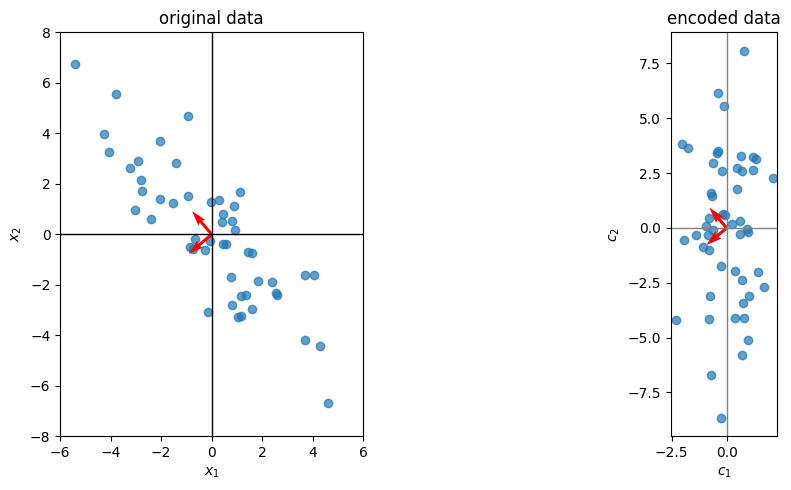

In [32]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left panel
ax[0].scatter(X[0, :], X[1, :], alpha=0.7)
ax[0].quiver(0, 0, pc1[0], pc1[1], color='red', scale=10, width=0.01)
ax[0].quiver(0, 0, pc2[0], pc2[1], color='red', scale=10, width=0.01)

ax[0].set_title("original data")
ax[0].set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$")

ax[0].set_xlim([-6, 6])
ax[0].set_ylim([-8, 8])
ax[0].axhline(0, color='black', linewidth=1)
ax[0].axvline(0, color='black', linewidth=1)

ax[0].set_aspect('equal')


# Right panel
# Rotate and flip to match book orientation
C_rot = np.vstack([C[1, :], C[0, :]])
C_rot[1, :] = -C_rot[1, :]

ax[1].scatter(C_rot[0, :], C_rot[1, :], alpha=0.7)
ax[1].quiver(0, 0, pc1[0], pc1[1], color='red', scale=4, width=0.03)
ax[1].quiver(0, 0, pc2[0], pc2[1], color='red', scale=4, width=0.03)
ax[1].set_title("encoded data")
ax[1].set_xlabel("$c_1$")
ax[1].set_ylabel("$c_2$")

ax[1].axhline(0, color='gray', linewidth=1)
ax[1].axvline(0, color='gray', linewidth=1)

ax[1].set_aspect('equal')


plt.tight_layout()
plt.show()